<a href="https://colab.research.google.com/github/sairiamu/ML-DL-collection/blob/main/Mini_RAE_Generator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧬 Mini-RAE: Generate Images from a Frozen DINOv2 Latent Space

**RAE = Representation Autoencoder.** Instead of *learning* a latent space from scratch (like Stable Diffusion's VAE), we **borrow** one from a pretrained vision model (DINOv2) and only train a **decoder** that maps those semantic latents back to pixels.

```
TRAINING                                      GENERATION
Image ─► DINOv2 (frozen) ─► z ─► Decoder ─► Image'      noise ─► [sampler] ─► z_new ─► Decoder ─► new image
                                  ▲ only this is trained
```

**Runtime:** `Runtime ▸ Change runtime type ▸ T4 GPU` (free tier is enough, ~5 GB VRAM).

### What you will build
| Part | What | Why it matters |
|---|---|---|
| 1 | Frozen DINOv2 encoder | Free, strong semantic features |
| 2 | Conv decoder, trained with MSE | Turns semantics back into pixels |
| 3 | Gaussian sampling of latents | Simplest possible "generator" |
| 4 | Tiny latent diffusion (DDPM) | Much better generator, the core idea of RAE + DiT |

## 0. The mechanism in plain words

**Why does generation reduce to "sample a latent, then decode"?**
If the decoder is a good function `D(z) → image` for latents `z` that come from real images, then any *new* `z` that looks like a real latent will decode to a *new, plausible* image. So image generation becomes: **model the distribution of `z`**, a 384-number vector, instead of the distribution of 12,288 raw pixel values.

**Why use a frozen DINOv2 as the encoder?**
DINOv2 was self-supervised on ~142M images. Its features already encode *what* is in the image (object, shape, texture, pose). A VAE latent only has to be *reconstructable*. A DINO latent is *semantic*, so the space is smoother, and nearby latents mean similar content. That makes sampling and diffusion in that space easier.

**Why is only the decoder trained?**
Gradients flow back through the decoder only. The encoder has `requires_grad=False`, and we even run it once and cache the outputs, so training is very cheap.

**Honest caveat:** here we use only DINO's `CLS` token (one 384-d vector per image). It is a *lossy* summary: reconstructions will be blurry "gists". The full RAE keeps all 256 patch tokens. We cover that in the last section.

## 1. Setup

In [1]:
!pip -q install transformers datasets accelerate

In [2]:
import math, copy, time
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import transforms
from transformers import AutoModel

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(0); np.random.seed(0)
print("device:", device, "|", torch.cuda.get_device_name(0) if device == "cuda" else "no GPU (will be slow!)")

# ---------------- Config: tweak here ----------------
DATASET   = "cifar10"      # "cifar10" (easy) or "pokemon" (fun, ~800 imgs, small)
N_IMAGES  = 50000          # max images to use
IMG       = 64             # output resolution of the decoder
BATCH     = 256
DEC_EPOCHS = 30            # decoder training epochs
DIFF_STEPS = 20000         # diffusion training steps
T          = 1000          # diffusion timesteps

device: cuda | Tesla T4


## 2. Load the frozen DINOv2 encoder

**Mechanism.** DINOv2 is a Vision Transformer (ViT):

1. The 224×224 image is cut into **14×14 pixel patches** → 16×16 = **256 patches**.
2. Each patch becomes a 384-d token (for `dinov2-small`). A special learnable **`[CLS]` token** is prepended → **257 tokens**.
3. Transformer layers let all tokens exchange information via attention. The `[CLS]` token ends up summarising the *whole image*.

So the output `last_hidden_state` has shape `(B, 257, 384)`. We take index `0` (the CLS token) as our latent `z`.

**Freezing**: `eval()` turns off dropout, and `requires_grad=False` stops gradients and saves memory.

In [3]:
encoder = AutoModel.from_pretrained("facebook/dinov2-small").to(device).eval()
for p in encoder.parameters():
    p.requires_grad = False

# DINOv2 was trained with ImageNet normalisation. Skipping this degrades features.
MEAN = torch.tensor([0.485, 0.456, 0.406], device=device).view(1, 3, 1, 1)
STD  = torch.tensor([0.229, 0.224, 0.225], device=device).view(1, 3, 1, 1)

@torch.no_grad()
def encode(x01):
    # x01: (B,3,H,W) floats in [0,1] -> z: (B,384)
    x = F.interpolate(x01, size=224, mode="bicubic", align_corners=False).clamp(0, 1)
    x = (x - MEAN) / STD
    with torch.autocast(device_type="cuda", dtype=torch.float16, enabled=(device == "cuda")):
        out = encoder(pixel_values=x).last_hidden_state   # (B,257,384)
    return out[:, 0].float()                              # CLS token -> (B,384)

# sanity check
dummy = torch.rand(2, 3, IMG, IMG, device=device)
print("latent shape:", encode(dummy).shape)   # expect (2, 384)

config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 88.2MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

latent shape: torch.Size([2, 384])


## 3. Dataset

We load images at **64×64**. This is the *target* the decoder must reproduce. Inside `encode()` we upsample to 224 for DINO (CIFAR-10 is natively 32×32, so this is the same information either way).

> Want Pokémon? Set `DATASET = "pokemon"` in the config cell and re-run from there. It's small (~800 images), so use `N_IMAGES` as is and expect more memorisation.

In [4]:
tfm = transforms.Compose([transforms.Resize((IMG, IMG)), transforms.ToTensor()])

if DATASET == "cifar10":
    from torchvision.datasets import CIFAR10
    ds = CIFAR10(root="./data", train=True, download=True, transform=tfm)
elif DATASET == "pokemon":
    from datasets import load_dataset
    hf = load_dataset("huggan/pokemon", split="train")
    class HFImages(Dataset):
        def __len__(self): return len(hf)
        def __getitem__(self, i): return tfm(hf[i]["image"].convert("RGB"))
    ds = HFImages()
else:
    raise ValueError(DATASET)

ds = Subset(ds, range(min(N_IMAGES, len(ds))))
print("images:", len(ds))

100%|██████████| 170M/170M [00:07<00:00, 24.1MB/s]


images: 50000


## 4. Extract and cache the latents (the encoder runs only once)

Because the encoder is frozen, `z = Encoder(image)` never changes. Computing it **once** and caching it makes decoder training very fast; otherwise we'd re-run a ViT every epoch.

We also keep the 64×64 images as `uint8` (4× smaller than float32) to use as reconstruction targets.

In [5]:
loader = DataLoader(ds, batch_size=BATCH, shuffle=False, num_workers=2)

lat_list, img_list = [], []
t0 = time.time()
for batch in loader:
    x = batch[0] if isinstance(batch, (list, tuple)) else batch   # CIFAR gives (img,label)
    x = x.to(device)
    lat_list.append(encode(x).cpu())
    img_list.append((x * 255).round().byte().cpu())

latents = torch.cat(lat_list)        # (N,384) float
images  = torch.cat(img_list)        # (N,3,64,64) uint8
print(f"latents {tuple(latents.shape)}, images {tuple(images.shape)}, {time.time()-t0:.0f}s")

latents (50000, 384), images (50000, 3, 64, 64), 69s


## 5. The decoder

**Why not the original big MLP (`Linear → 64·64·3`)?**
A fully-connected layer from 4096 → 12288 has ~50M weights and no notion of *spatial locality*; it must learn every pixel relationship independently. A **transposed-convolution** decoder instead:

```
z (384) ─Linear─► 512×4×4 ─ConvT─► 256×8×8 ─ConvT─► 128×16×16 ─ConvT─► 64×32×32 ─ConvT─► 32×64×64 ─Conv─► 3×64×64
```

- Each `ConvTranspose2d(k=4, stride=2, pad=1)` **doubles** the resolution and reuses the same small kernel across the image (weight sharing = spatial prior).
- `BatchNorm + ReLU` stabilise and add non-linearity.
- Final `Sigmoid` squashes outputs into `[0,1]`, matching pixel range.

In [6]:
def up(i, o):
    return nn.Sequential(nn.ConvTranspose2d(i, o, 4, 2, 1), nn.BatchNorm2d(o), nn.ReLU(True))

class Decoder(nn.Module):
    def __init__(self, zdim=384):
        super().__init__()
        self.fc = nn.Linear(zdim, 512 * 4 * 4)
        self.net = nn.Sequential(
            nn.ReLU(True),
            up(512, 256),   # 4  -> 8
            up(256, 128),   # 8  -> 16
            up(128, 64),    # 16 -> 32
            up(64, 32),     # 32 -> 64
            nn.Conv2d(32, 3, 3, padding=1),
            nn.Sigmoid(),
        )
    def forward(self, z):
        return self.net(self.fc(z).view(-1, 512, 4, 4))

decoder = Decoder().to(device)
print("decoder params: %.1fM" % (sum(p.numel() for p in decoder.parameters()) / 1e6))
print("output shape:", decoder(torch.randn(2, 384, device=device)).shape)   # (2,3,64,64)

decoder params: 5.9M
output shape: torch.Size([2, 3, 64, 64])


## 6. Train the decoder

**Objective:** minimise `MSE( Decoder(z), original_image )`.

**Mechanism of one step**
1. Take a batch of cached `z` and their images.
2. `pred = decoder(z)`, the forward pass.
3. `loss = mean((pred - target)²)`.
4. `loss.backward()` computes ∂loss/∂weights **for the decoder only** (z is a constant input).
5. `optimizer.step()` nudges weights downhill.

**Expect blur.** MSE predicts the *average* of all plausible images for a given `z`, and averages are blurry. Sharper results need perceptual/GAN losses (see the last section).

In [7]:
Z = latents.to(device)
X = images.to(device)                         # uint8 on GPU (50k*12288 B ≈ 0.6 GB)
N = Z.shape[0]

opt = torch.optim.AdamW(decoder.parameters(), lr=1e-3, weight_decay=1e-4)
steps_per_epoch = math.ceil(N / BATCH)
sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=1e-3, total_steps=DEC_EPOCHS * steps_per_epoch)

decoder.train()
for epoch in range(DEC_EPOCHS):
    perm = torch.randperm(N, device=device)
    total = 0.0
    for i in range(0, N, BATCH):
        idx = perm[i:i + BATCH]
        z, target = Z[idx], X[idx].float() / 255
        loss = F.mse_loss(decoder(z), target)
        opt.zero_grad(set_to_none=True)
        loss.backward()
        opt.step(); sched.step()
        total += loss.item() * len(idx)
    if epoch % 5 == 0 or epoch == DEC_EPOCHS - 1:
        print(f"epoch {epoch+1:02d}/{DEC_EPOCHS}  mse {total/N:.5f}")
decoder.eval();

epoch 01/30  mse 0.04935
epoch 06/30  mse 0.02683
epoch 11/30  mse 0.01887
epoch 16/30  mse 0.01287
epoch 21/30  mse 0.00898
epoch 26/30  mse 0.00698
epoch 30/30  mse 0.00658


## 7. Check reconstructions: `Image → z → Image'`

Top row = originals, bottom row = decoded from the 384-d DINO latent. If shapes/colours/objects roughly match, the latent space carries real semantic information, and the encoder-decoder pair works.

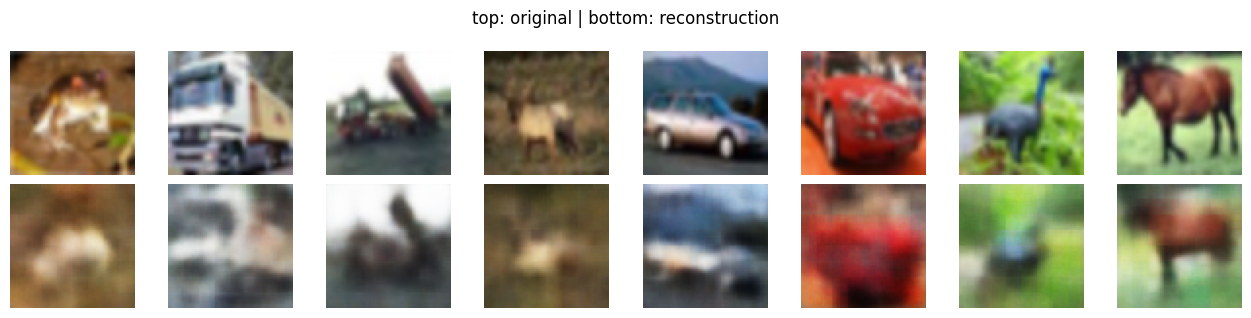

In [8]:
def show(imgs, nrow=8, title=None):
    imgs = imgs.detach().cpu().clamp(0, 1)
    n = imgs.shape[0]; ncol = math.ceil(n / nrow)
    fig, axs = plt.subplots(ncol, nrow, figsize=(nrow * 1.6, ncol * 1.6))
    for a, im in zip(np.array(axs).ravel(), imgs):
        a.imshow(im.permute(1, 2, 0)); a.axis("off")
    for a in np.array(axs).ravel()[n:]: a.axis("off")
    if title: fig.suptitle(title)
    plt.tight_layout(); plt.show()

with torch.no_grad():
    idx = torch.arange(8)
    rec = decoder(Z[idx])
show(torch.cat([X[idx].float() / 255, rec]), nrow=8, title="top: original | bottom: reconstruction")

## 8. Generation, v1: fit a Gaussian over latents

**Idea.** Treat the cached latents as samples from some distribution. Approximate it with a Gaussian and sample from it.

- **Diagonal Gaussian** (the original idea): independent mean/std per dimension. Ignores correlations between dimensions.
- **Full-covariance Gaussian**: also models correlations (`cov`, a 384×384 matrix). This is a **big** improvement because DINO dimensions are strongly correlated.

Neither can capture *multi-modal* structure (e.g. "cat cluster" vs "truck cluster"), so samples are often fuzzy blends. That motivates diffusion.

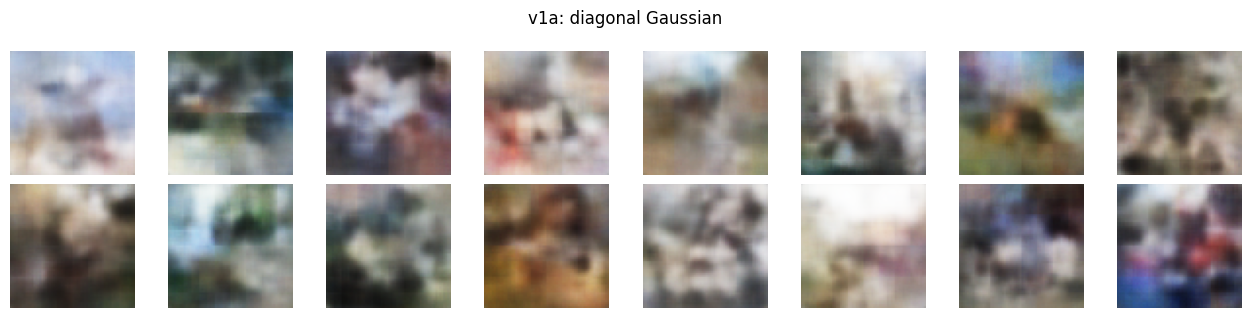

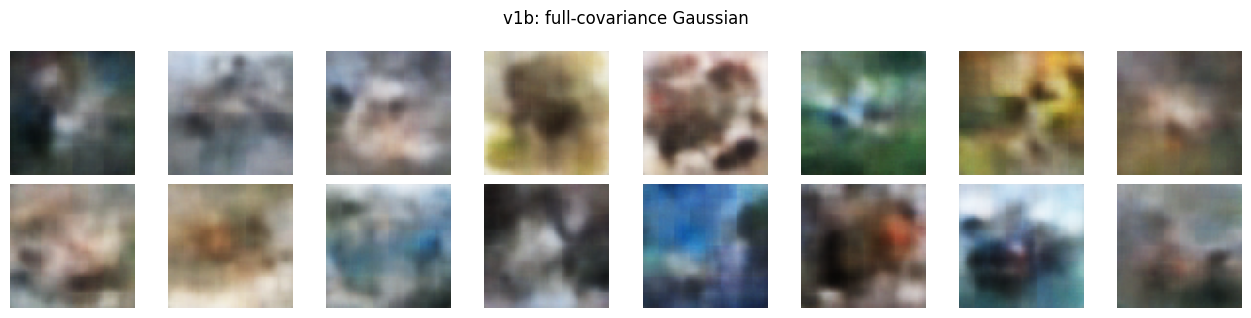

In [9]:
mean = Z.mean(0)
std  = Z.std(0)

with torch.no_grad():
    z_diag = torch.randn(16, 384, device=device) * std + mean
    imgs_diag = decoder(z_diag)

cov = torch.cov(Z.T) + 1e-4 * torch.eye(384, device=device)
mvn = torch.distributions.MultivariateNormal(mean, covariance_matrix=cov)
with torch.no_grad():
    imgs_full = decoder(mvn.sample((16,)))

show(imgs_diag, nrow=8, title="v1a: diagonal Gaussian")
show(imgs_full, nrow=8, title="v1b: full-covariance Gaussian")

## 9. Generation, v2: a tiny diffusion model in latent space

### The idea (DDPM)
**Forward process (fixed, no learning):** gradually destroy a clean latent `z₀` with Gaussian noise over `T=1000` steps:

$$z_t = \sqrt{\bar\alpha_t}\, z_0 + \sqrt{1-\bar\alpha_t}\, \varepsilon, \qquad \varepsilon \sim \mathcal N(0, I)$$

`ᾱ_t` shrinks from ≈1 (clean) to ≈0 (pure noise) as `t` grows. A neat property: we can jump to **any** `t` in one shot, with no need to simulate all steps.

**Reverse process (learned):** train a network `ε_θ(z_t, t)` to **predict the noise** that was added. Loss: `‖ε − ε_θ(z_t, t)‖²`.

**Sampling:** start from pure noise `z_T`, then repeatedly use the predicted noise to take one small denoising step `z_t → z_{t-1}` until you reach `z₀`. Then `Decoder(z₀)` gives an image.

### Why an MLP, not a transformer?
Our latent is a *single vector*, not a sequence of tokens, so there is nothing for attention to attend over. A residual MLP conditioned on `t` is the right-sized tool. (In the full RAE + DiT, the latent is a *grid of patch tokens*, and a transformer is the right tool. See last section.)

### Details
- **Standardise latents** (zero mean, unit variance per dimension) so they match the unit-variance noise.
- **Time embedding**: sinusoidal features of `t` so the network knows the noise level.
- **EMA** (exponential moving average of weights): averaged weights give noticeably cleaner samples.

In [10]:
# ---- noise schedule ----
betas = torch.linspace(1e-4, 0.02, T, device=device)
alphas = 1.0 - betas
abar = torch.cumprod(alphas, dim=0)           # ᾱ_t

# ---- standardised latents ----
z_mu, z_sd = Z.mean(0, keepdim=True), Z.std(0, keepdim=True) + 1e-6
Zn = (Z - z_mu) / z_sd

# ---- denoiser network ----
class TimeEmb(nn.Module):
    def __init__(self, dim=128):
        super().__init__(); self.dim = dim
    def forward(self, t):
        half = self.dim // 2
        freqs = torch.exp(-math.log(10000) * torch.arange(half, device=t.device) / half)
        a = t[:, None].float() * freqs[None]
        return torch.cat([a.sin(), a.cos()], dim=-1)

class ResBlock(nn.Module):
    def __init__(self, w):
        super().__init__()
        self.norm = nn.LayerNorm(w)
        self.fc1, self.fc2 = nn.Linear(w, w), nn.Linear(w, w)
        self.t_proj = nn.Linear(w, w)           # injects the timestep into every block
    def forward(self, x, te):
        h = self.fc1(self.norm(x)) + self.t_proj(te)
        return x + self.fc2(F.silu(h))          # residual connection

class Denoiser(nn.Module):
    def __init__(self, zdim=384, w=1024, depth=6):
        super().__init__()
        self.inp = nn.Linear(zdim, w)
        self.temb = nn.Sequential(TimeEmb(128), nn.Linear(128, w), nn.SiLU(), nn.Linear(w, w))
        self.blocks = nn.ModuleList([ResBlock(w) for _ in range(depth)])
        self.out = nn.Sequential(nn.LayerNorm(w), nn.Linear(w, zdim))
    def forward(self, z, t):
        te = self.temb(t)
        h = self.inp(z)
        for b in self.blocks: h = b(h, te)
        return self.out(h)                      # predicted noise ε̂

denoiser = Denoiser().to(device)
ema = copy.deepcopy(denoiser).eval()
print("denoiser params: %.1fM" % (sum(p.numel() for p in denoiser.parameters()) / 1e6))

denoiser params: 20.9M


### Train the denoiser
Each step:
1. Sample a batch of clean latents `z₀`, random timesteps `t`, random noise `ε`.
2. Build `z_t` with the closed-form forward formula.
3. Predict `ε̂ = ε_θ(z_t, t)` and minimise `MSE(ε̂, ε)`.
4. Update the EMA copy.

In [11]:
opt_d = torch.optim.AdamW(denoiser.parameters(), lr=3e-4, weight_decay=1e-4)
sched_d = torch.optim.lr_scheduler.CosineAnnealingLR(opt_d, DIFF_STEPS)
DB = 512
t0 = time.time()
denoiser.train()
for step in range(1, DIFF_STEPS + 1):
    z0 = Zn[torch.randint(0, N, (DB,), device=device)]
    t = torch.randint(0, T, (DB,), device=device)
    eps = torch.randn_like(z0)
    ab = abar[t][:, None]
    zt = ab.sqrt() * z0 + (1 - ab).sqrt() * eps          # forward noising
    loss = F.mse_loss(denoiser(zt, t), eps)              # predict the noise
    opt_d.zero_grad(set_to_none=True); loss.backward()
    nn.utils.clip_grad_norm_(denoiser.parameters(), 1.0)
    opt_d.step(); sched_d.step()
    with torch.no_grad():                                # EMA update
        for pe, p in zip(ema.parameters(), denoiser.parameters()):
            pe.mul_(0.999).add_(p.detach(), alpha=0.001)
    if step % 2000 == 0:
        print(f"step {step:6d}/{DIFF_STEPS}  loss {loss.item():.4f}  ({time.time()-t0:.0f}s)")

step   2000/20000  loss 0.2202  (67s)
step   4000/20000  loss 0.1961  (132s)
step   6000/20000  loss 0.2085  (197s)
step   8000/20000  loss 0.1881  (263s)
step  10000/20000  loss 0.1753  (328s)
step  12000/20000  loss 0.1790  (393s)
step  14000/20000  loss 0.1702  (459s)
step  16000/20000  loss 0.1677  (524s)
step  18000/20000  loss 0.1734  (589s)
step  20000/20000  loss 0.1783  (654s)


### Sample: `noise → diffusion → latent → decoder → image`

One reverse step (DDPM ancestral sampling):

$$z_{t-1} = \frac{1}{\sqrt{\alpha_t}}\Big(z_t - \frac{\beta_t}{\sqrt{1-\bar\alpha_t}}\,\hat\varepsilon\Big) + \sigma_t\, \mathbf{n}, \quad \sigma_t=\sqrt{\beta_t}$$

Read it as: *subtract the predicted noise (scaled), then add back a little fresh randomness* (except at the final step). After 1000 such steps, pure noise becomes a plausible latent.

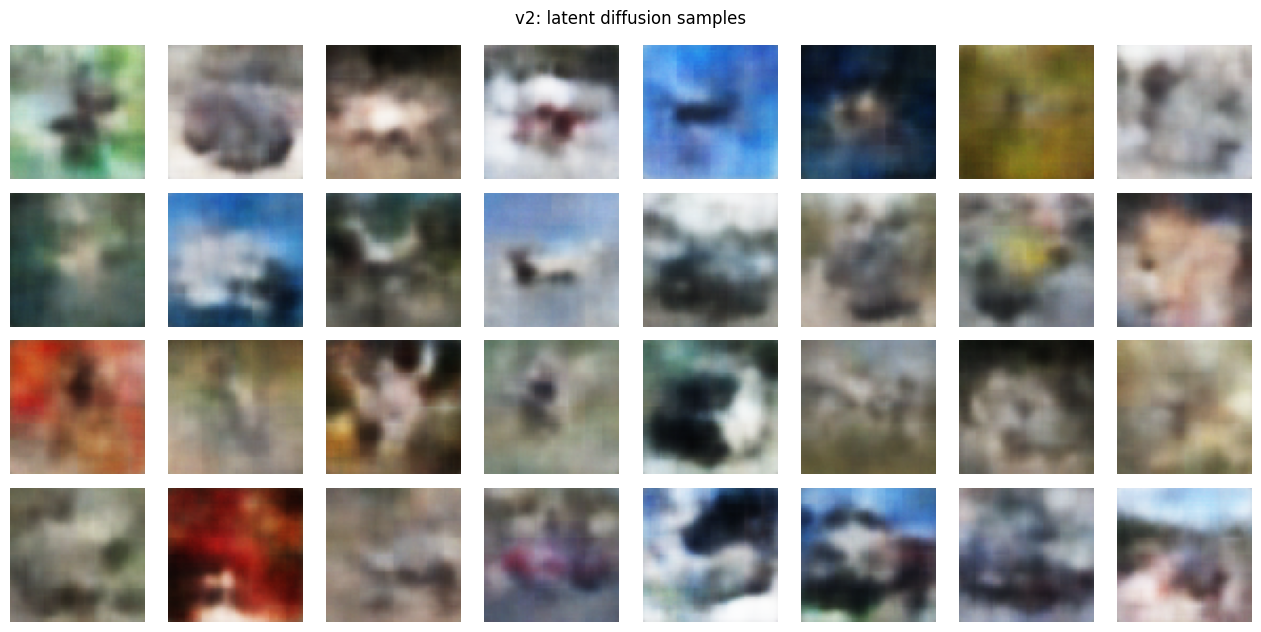

In [12]:
@torch.no_grad()
def sample_latents(model, n=16):
    z = torch.randn(n, 384, device=device)
    for t in reversed(range(T)):
        tt = torch.full((n,), t, device=device, dtype=torch.long)
        eps_hat = model(z, tt)
        coef = betas[t] / (1 - abar[t]).sqrt()
        z = (z - coef * eps_hat) / alphas[t].sqrt()
        if t > 0:
            z = z + betas[t].sqrt() * torch.randn_like(z)
    return z * z_sd + z_mu                       # undo standardisation

z_gen = sample_latents(ema, 32)
with torch.no_grad():
    imgs_diff = decoder(z_gen)
show(imgs_diff, nrow=8, title="v2: latent diffusion samples")

### Compare all three generators

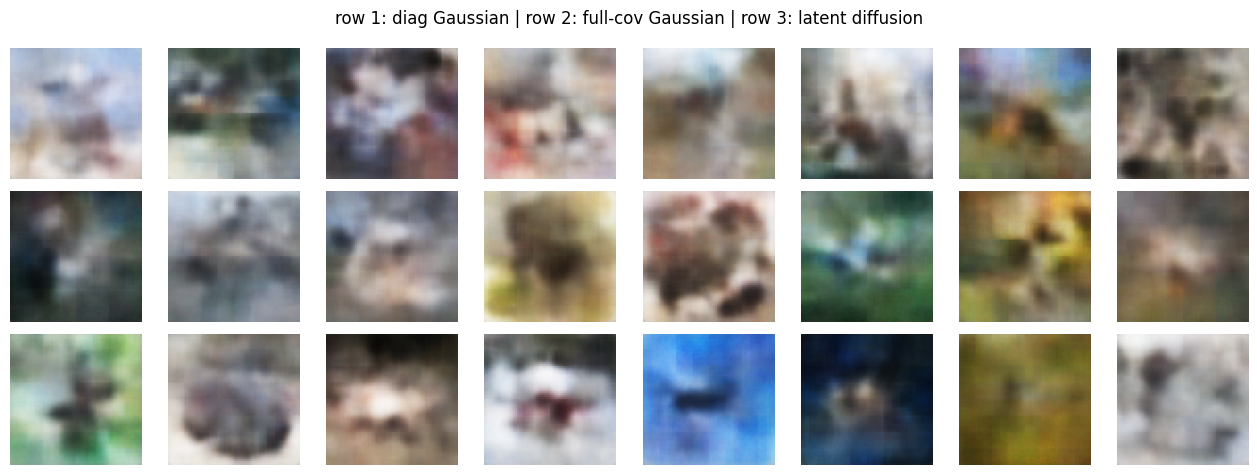

In [13]:
show(torch.cat([imgs_diag[:8], imgs_full[:8], imgs_diff[:8]]), nrow=8,
     title="row 1: diag Gaussian | row 2: full-cov Gaussian | row 3: latent diffusion")

## 10. Are we just memorising?
For each generated latent, find its **nearest training latent** (cosine similarity). A value near 1.0 means a near-copy of a training image. Moderate values suggest genuinely new combinations.

mean nearest-neighbour cosine: 0.656  (max 0.788)


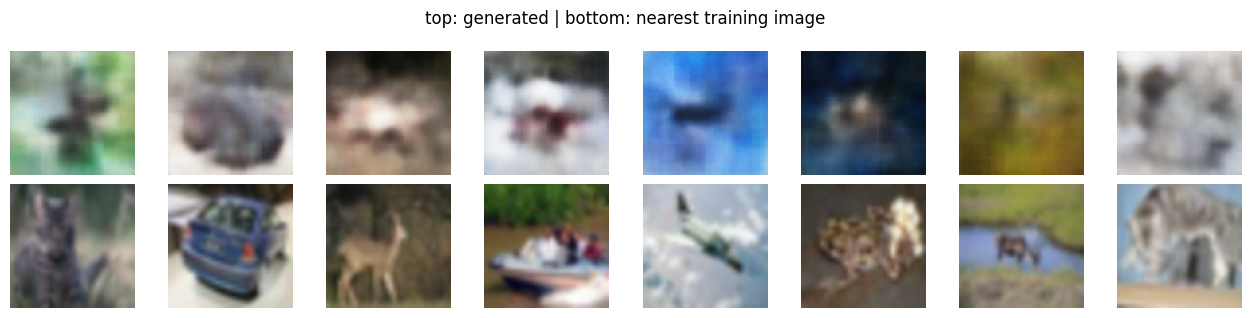

In [14]:
zn = F.normalize(z_gen, dim=-1); Zr = F.normalize(Z, dim=-1)
sims, nn_idx = (zn @ Zr.T).max(dim=1)
print("mean nearest-neighbour cosine: %.3f  (max %.3f)" % (sims.mean(), sims.max()))
k = 8
show(torch.cat([imgs_diff[:k], X[nn_idx[:k]].float() / 255]), nrow=k, title="top: generated | bottom: nearest training image")

## 11. Limitations and what to try next

**Why quality is limited here**
| Limit | Cause | Fix |
|---|---|---|
| Blurry output | MSE averages plausible images | Add L1 + perceptual (LPIPS) and/or GAN loss |
| Lost detail | Only the 1×384 `CLS` token | Use **all 256 patch tokens** (16×16×384) |
| Small res | 64×64 decoder | Deeper decoder / progressive upsampling |

**Resource usage (T4, 16 GB)**
| Component | VRAM |
|---|---|
| DINOv2-small | ~1 GB |
| Decoder + optimizer | < 1 GB |
| Cached data + batches | 2–3 GB |
| **Total** | **~5 GB** |

### Phase 2: the real RAE + DiT
1. Keep **patch tokens** `(B, 256, 384)` instead of CLS only: `out[:, 1:]`.
2. Decoder becomes a **ViT decoder**: tokens → transformer → un-patchify (`256 tokens → 16×16 grid → pixels`).
3. Replace the MLP denoiser with a **DiT** (Diffusion Transformer): it treats the 256 latent tokens as a sequence and conditions on `t` via **adaLN** (timestep-dependent LayerNorm scale/shift).
4. Add classifier-free guidance with class labels for controllable generation.

```
noise (256×384) ─► DiT ─► semantic latent grid ─► ViT decoder ─► image
```

### Experiments to try
- Swap `dinov2-small` for `dinov2-base` (768-d, update `384` → `768`).
- Compare diagonal vs. full-cov vs. diffusion with a fixed random seed.
- Switch `DATASET = "pokemon"` and watch how structured the latent space is.
- Reduce `T` to 250 or use DDIM sampling for faster generation.